## Assignment 6: Machine Translation Benchmark

This notebook compares **2 translation models from 2 different families** using **2 data types** across a **4-language blend**:
- Hindi (`hi`)
- English (`en`)
- Marathi (`mr`)
- Spanish (`es`)

- 2 models: `facebook/nllb-200-distilled-600M` (NLLB family), `facebook/m2m100_418M` (M2M100 family)
- 2 data types:
  1. Public multilingual corpus (`facebook/flores` from Hugging Face Datasets)
  2. Custom/domain sentence set (manually curated)
The following three evaluation metrics are used to measure translation quality:

- **BLEU** (Bilingual Evaluation Understudy): Measures n-gram overlap between the machine translation and reference translation. Higher scores indicate better lexical matching. Range: 0-100.
- **chrF** (Character n-gram F-score): Evaluates character-level similarity between translations, making it more robust to morphologically rich languages. Higher scores are better. Range: 0-100.
- **TER** (Translation Edit Rate): Counts the minimum number of edits (insertions, deletions, substitutions, shifts) needed to transform the hypothesis into the reference. Lower scores indicate fewer edits required, meaning better quality.

In [19]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from datasets import load_dataset
from tqdm.auto import tqdm
import evaluate

from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cpu


In [20]:
# Language code mapping per model family
NLLB_LANGS = {
    "en": "eng_Latn",
    "hi": "hin_Deva",
    "mr": "mar_Deva",
    "es": "spa_Latn",
}

M2M_LANGS = {
    "en": "en",
    "hi": "hi",
    "mr": "mr",
    "es": "es",
}

# ---------- Data Type 1: Multilingual Corpus (OPUS-100 parallel corpora) ----------
# Using three corpus slices and combining them into a 4-language table.
corpus_sample_size = 12

en_hi = load_dataset("opus100", "en-hi", split=f"test[:{corpus_sample_size}]")
en_mr = load_dataset("opus100", "en-mr", split=f"test[:{corpus_sample_size}]")
en_es = load_dataset("opus100", "en-es", split=f"test[:{corpus_sample_size}]")

corpus_df = pd.DataFrame(
    {
        "en": [x["en"] for x in en_hi["translation"]],
        "hi": [x["hi"] for x in en_hi["translation"]],
        "mr": [x["mr"] for x in en_mr["translation"]],
        "es": [x["es"] for x in en_es["translation"]],
    }
)

# ---------- Data Type 2: Custom/Domain Data ----------
custom_rows = [
    {
        "en": "Please submit your assignment before Friday.",
        "hi": "कृपया शुक्रवार से पहले अपना असाइनमेंट जमा करें।",
        "mr": "कृपया शुक्रवारीपूर्वी तुमचे असाइनमेंट जमा करा.",
        "es": "Por favor, envía tu tarea antes del viernes.",
    },
    {
        "en": "The train is delayed due to heavy rain.",
        "hi": "भारी बारिश के कारण ट्रेन देर से है।",
        "mr": "मुसळधार पावसामुळे रेल्वेला उशीर झाला आहे.",
        "es": "El tren está retrasado debido a la fuerte lluvia.",
    },
    {
        "en": "Can you explain this concept with an example?",
        "hi": "क्या आप इस अवधारणा को उदाहरण के साथ समझा सकते हैं?",
        "mr": "तुम्ही ही संकल्पना उदाहरणासह समजावू शकता का?",
        "es": "¿Puedes explicar este concepto con un ejemplo?",
    },
    {
        "en": "I need to book a doctor appointment for tomorrow.",
        "hi": "मुझे कल के लिए डॉक्टर की अपॉइंटमेंट बुक करनी है।",
        "mr": "मला उद्यासाठी डॉक्टरांची अपॉइंटमेंट बुक करायची आहे.",
        "es": "Necesito reservar una cita con el médico para mañana.",
    },
    {
        "en": "Learning multiple languages improves cognitive flexibility.",
        "hi": "कई भाषाएँ सीखना संज्ञानात्मक लचीलापन बढ़ाता है।",
        "mr": "अनेक भाषा शिकल्याने संज्ञानात्मक लवचिकता वाढते.",
        "es": "Aprender varios idiomas mejora la flexibilidad cognitiva.",
    },
]
custom_df = pd.DataFrame(custom_rows)

print("Corpus data shape:", corpus_df.shape)
print("Custom data shape:", custom_df.shape)
corpus_df.head(3)

Corpus data shape: (12, 4)
Custom data shape: (5, 4)


,en,hi,mr,es
0,"Give shots of injections or pills, but he must...",सुई लगाओ या गोली खिलाओ लेकिन इसे जल्दी से ठीक ...,केनिया ब्रिटिश वसाहत असायची.,"Si su país produjo SAO para estos usos, sírvas..."
1,"They said, “O Shuaib, we do not understand muc...",और वह लोग कहने लगे ऐ शुएब जो बाते तुम कहते हो ...,"टॉम जाईलच, मेरीने काहीही म्हटलं तरीही.","# Juvie el gran hombre, ¿quién podría ser sino..."
2,- Yeah.,- हाँ.,त्यांना गायला व नाचायला आवडतं.,El planeta madre se está agotando.


In [21]:
# Define the 2 models from 2 families
MODEL_CONFIG = {
    "NLLB": "facebook/nllb-200-distilled-600M",
    "M2M100": "facebook/m2m100_418M",
}

models = {}
for family, model_name in MODEL_CONFIG.items():
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSeq2SeqLM.from_pretrained(model_name).to(device)
    model.eval()
    models[family] = {"tokenizer": tokenizer, "model": model, "name": model_name}

print("Loaded models:")
for k, v in models.items():
    print(f"- {k}: {v['name']}")

Loaded models:
- NLLB: facebook/nllb-200-distilled-600M
- M2M100: facebook/m2m100_418M


In [22]:
def translate_batch(model_family, texts, src_key, tgt_key, max_new_tokens=128):
    """Translate a list of texts using selected model family."""
    bundle = models[model_family]
    tokenizer = bundle["tokenizer"]
    model = bundle["model"]

    if model_family == "NLLB":
        src_lang = NLLB_LANGS[src_key]
        tgt_lang = NLLB_LANGS[tgt_key]
        tokenizer.src_lang = src_lang
        encoded = tokenizer(texts, return_tensors="pt", padding=True, truncation=True).to(device)
        forced_bos = tokenizer.convert_tokens_to_ids(tgt_lang)
        with torch.no_grad():
            generated = model.generate(**encoded, forced_bos_token_id=forced_bos, max_new_tokens=max_new_tokens)
    else:  # M2M100
        src_lang = M2M_LANGS[src_key]
        tgt_lang = M2M_LANGS[tgt_key]
        tokenizer.src_lang = src_lang
        encoded = tokenizer(texts, return_tensors="pt", padding=True, truncation=True).to(device)
        forced_bos = tokenizer.get_lang_id(tgt_lang)
        with torch.no_grad():
            generated = model.generate(**encoded, forced_bos_token_id=forced_bos, max_new_tokens=max_new_tokens)

    return tokenizer.batch_decode(generated, skip_special_tokens=True)


def evaluate_set(df, data_type, language_pairs):
    bleu_metric = evaluate.load("sacrebleu")
    chrf_metric = evaluate.load("chrf")
    ter_metric = evaluate.load("ter")

    rows = []
    for src, tgt in language_pairs:
        src_texts = df[src].astype(str).tolist()
        ref_texts = df[tgt].astype(str).tolist()
        wrapped_refs = [[ref] for ref in ref_texts]

        for model_family in models.keys():
            hyps = translate_batch(
                model_family=model_family,
                texts=src_texts,
                src_key=src,
                tgt_key=tgt,
            )

            bleu_score = bleu_metric.compute(predictions=hyps, references=wrapped_refs)["score"]
            chrf_score = chrf_metric.compute(predictions=hyps, references=wrapped_refs)["score"]
            ter_score = ter_metric.compute(predictions=hyps, references=wrapped_refs)["score"]

            rows.append(
                {
                    "data_type": data_type,
                    "model_family": model_family,
                    "pair": f"{src}->{tgt}",
                    "BLEU": bleu_score,
                    "chrF": chrf_score,
                    "TER": ter_score,
                }
            )

    return pd.DataFrame(rows)

In [23]:
# Language pairs covering the 4-language blend
language_pairs = [
    ("en", "hi"),
    ("en", "mr"),
    ("en", "es"),
    ("hi", "en"),
    ("mr", "en"),
    ("es", "en"),
]

corpus_results = evaluate_set(corpus_df, "corpus_opus100", language_pairs)
custom_results = evaluate_set(custom_df, "custom_domain", language_pairs)

results_df = pd.concat([corpus_results, custom_results], ignore_index=True)
results_df.sort_values(["data_type", "pair", "model_family"]).reset_index(drop=True)

,data_type,model_family,pair,BLEU,chrF,TER
0,corpus_opus100,M2M100,en->es,0.452358,12.251883,122.699387
1,corpus_opus100,NLLB,en->es,0.460207,13.204325,117.791411
2,corpus_opus100,M2M100,en->hi,7.987475,23.171152,89.639640
3,corpus_opus100,NLLB,en->hi,6.917934,28.818345,84.234234
4,corpus_opus100,M2M100,en->mr,0.351841,7.620316,252.727273
5,corpus_opus100,NLLB,en->mr,0.387539,7.496565,280.000000
6,corpus_opus100,M2M100,es->en,0.438591,13.600410,139.726027
7,corpus_opus100,NLLB,es->en,0.445544,12.987126,136.986301
8,corpus_opus100,M2M100,hi->en,13.329529,41.782797,80.136986
9,corpus_opus100,NLLB,hi->en,28.722456,52.725257,60.273973


In [24]:
# Comparison summary (higher BLEU/chrF is better, lower TER is better)
summary = (
    results_df.groupby(["data_type", "model_family"], as_index=False)
    .agg({"BLEU": "mean", "chrF": "mean", "TER": "mean"})
    .round(2)
)
print(summary)

        data_type model_family   BLEU   chrF     TER
0  corpus_opus100       M2M100   3.81  17.36  131.96
1  corpus_opus100         NLLB   6.21  20.30  131.25
2   custom_domain       M2M100  46.64  66.70   39.33
3   custom_domain         NLLB  52.34  76.30   27.23


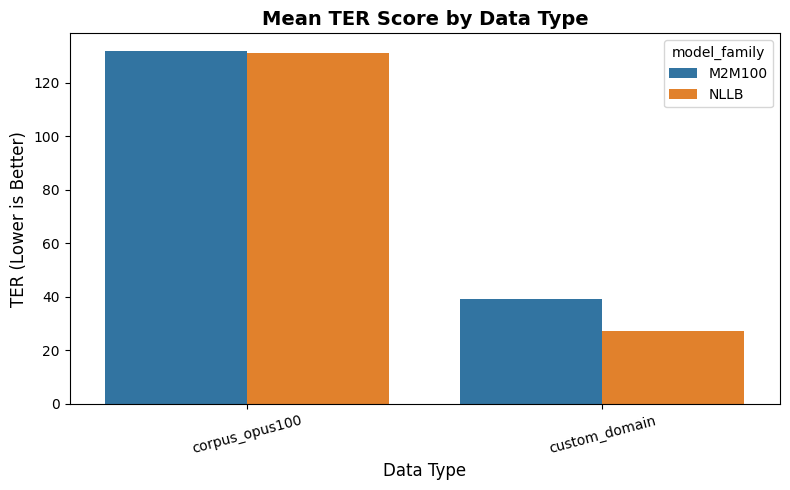

In [25]:
# Plot 3: TER Score Comparison
plt.figure(figsize=(8, 5))
sns.barplot(data=summary, x="data_type", y="TER", hue="model_family")
plt.title("Mean TER Score by Data Type", fontsize=14, fontweight="bold")
plt.xlabel("Data Type", fontsize=12)
plt.ylabel("TER (Lower is Better)", fontsize=12)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

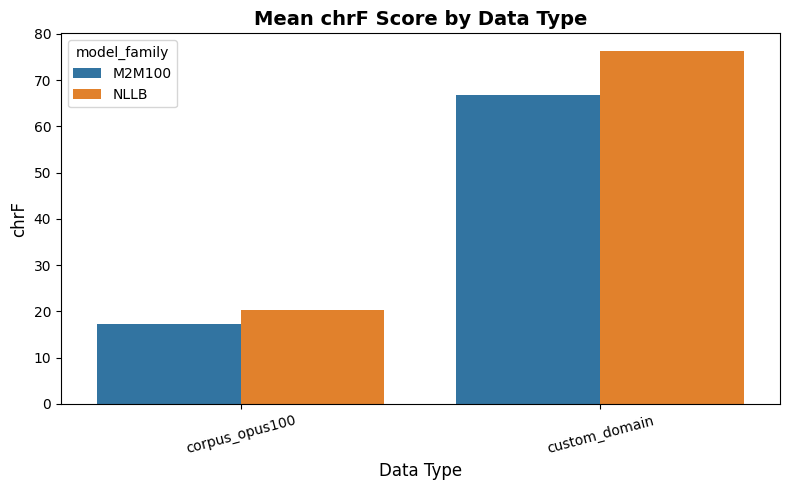

In [26]:
# Plot 2: chrF Score Comparison
plt.figure(figsize=(8, 5))
sns.barplot(data=summary, x="data_type", y="chrF", hue="model_family")
plt.title("Mean chrF Score by Data Type", fontsize=14, fontweight="bold")
plt.xlabel("Data Type", fontsize=12)
plt.ylabel("chrF", fontsize=12)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

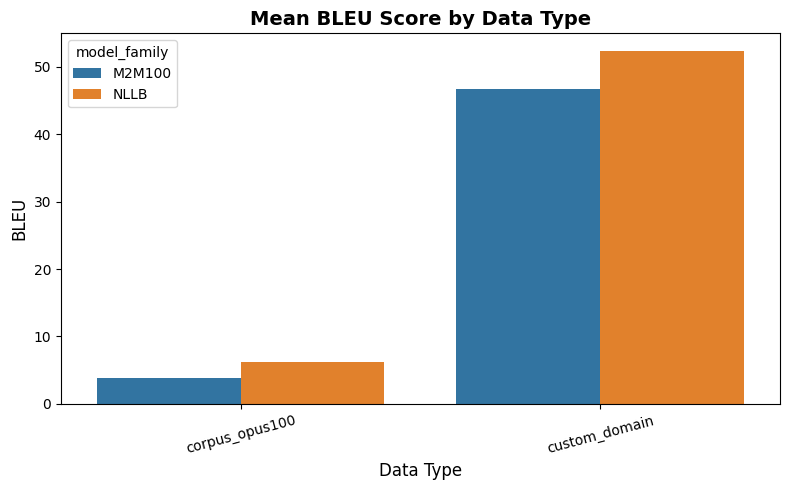

In [27]:
# Plot 1: BLEU Score Comparison
plt.figure(figsize=(8, 5))
sns.barplot(data=summary, x="data_type", y="BLEU", hue="model_family")
plt.title("Mean BLEU Score by Data Type", fontsize=14, fontweight="bold")
plt.xlabel("Data Type", fontsize=12)
plt.ylabel("BLEU", fontsize=12)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [28]:
# Display translated sentences for all language pairs and data types
print("=" * 120)
print("TRANSLATED SENTENCES COMPARISON")
print("=" * 120)

for data_name, data_df in [("CORPUS (OPUS-100)", corpus_df), ("CUSTOM DOMAIN DATA", custom_df)]:
    print(f"\n\n{'='*120}")
    print(f"DATA TYPE: {data_name}")
    print(f"{'='*120}\n")
    
    for src, tgt in language_pairs:
        print(f"\n{'-'*120}")
        print(f"Language Pair: {src.upper()} → {tgt.upper()}")
        print(f"{'-'*120}\n")
        
        src_texts = data_df[src].astype(str).tolist()
        ref_texts = data_df[tgt].astype(str).tolist()
        
        # Generate translations for this pair
        nllb_hyps = translate_batch("NLLB", src_texts, src, tgt)
        m2m_hyps = translate_batch("M2M100", src_texts, src, tgt)
        
        # Display first 3 examples per pair
        for idx in range(min(3, len(src_texts))):
            print(f"Example {idx+1}:")
            print(f"  SOURCE ({src.upper()}):      {src_texts[idx][:80]}")
            print(f"  REFERENCE ({tgt.upper()}):   {ref_texts[idx][:80]}")
            print(f"  NLLB:                    {nllb_hyps[idx][:80]}")
            print(f"  M2M100:                  {m2m_hyps[idx][:80]}")
            print()


TRANSLATED SENTENCES COMPARISON


DATA TYPE: CORPUS (OPUS-100)


------------------------------------------------------------------------------------------------------------------------
Language Pair: EN → HI
------------------------------------------------------------------------------------------------------------------------

Example 1:
  SOURCE (EN):      Give shots of injections or pills, but he must be alright soon.
  REFERENCE (HI):   सुई लगाओ या गोली खिलाओ लेकिन इसे जल्दी से ठीक करो.
  NLLB:                    इंजेक्शन या गोलियां दें, लेकिन वह जल्द ठीक हो जाएगा।
  M2M100:                  इंजेक्शन या गोलियों के झटके दें, लेकिन उसे जल्द ही ठीक होना चाहिए।

Example 2:
  SOURCE (EN):      They said, “O Shuaib, we do not understand much of what you say, and we see that
  REFERENCE (HI):   और वह लोग कहने लगे ऐ शुएब जो बाते तुम कहते हो उनमें से अक्सर तो हमारी समझ ही में
  NLLB:                    उन्होंने कहा, "ऐ शुऐब! हम तो तेरे कहने में से बहुत कुछ समझते नहीं और हम देखते है
  M2M10